In [7]:
import yaml
import numpy as np
import polars as pl
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [ ]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

new_anno_df = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""missense""","""am_pathogenicity""","""#FFCA28""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FB8C00""","""ESM1v""",-1
"""missense""","""score_pai3d""","""#D84315""","""PrimateAI-3D""",1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",-1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#00838F""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#26C6DA""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",-1


In [ ]:
new_anno_df = '/home/dnanexus/data_dir/flashzoi_proximal_variants_gencode40_avg_score.parquet'

fzdf = (
    pl.read_parquet(new_anno_df)
    .with_columns(
        fz_blood = (pl.col('RNA:blood_7531') + pl.col('RNA:blood_7532') + pl.col('RNA:blood_7533'))/3
    )
    .with_columns(
        max_fz_blood = pl.col('fz_blood').abs()
    )
    # .select(['id', 'region', 'fz_blood', 'max_fz_blood'])
)

fzdf

RNA:aortic smooth muscle cell male adult (21 years) and male adult (54 years)_6069,RNA:bladder microvascular endothelial cell male adult (46 years) and male adult (60 years)_6071,RNA:smooth muscle cell of bladder female adult (53 years) and male adult (62 years)_6073,RNA:bronchial epithelial cell female adult (40 years) and male adult (68 years)_6075,RNA:bronchial smooth muscle cell male adult (52 years) and male adult (59 years)_6077,RNA:endothelial cell of coronary artery female adult (41 years) and male adult (77 years)_6079,RNA:smooth muscle cell of the coronary artery female adult (53 years) and male adult (55 years)_6081,RNA:regular cardiac myocyte female adult (51 years) and male adult (48 years)_6083,RNA:dermis blood vessel endothelial cell female child (16 years) and male child (13 years)_6085,RNA:dermis lymphatic vessel endothelial cell female adult (45 years) and male child (6 years)_6087,RNA:dermis microvascular lymphatic vessel endothelial cell female adult (38 years) and female adult (64 years)_6089,RNA:nasal cavity respiratory epithelium epithelial cell of viscerocranial mucosa female adult (70 years) and male adult (46 years)_6091,RNA:pulmonary artery endothelial cell male adult (23 years) and male adult (52 years)_6093,RNA:smooth muscle cell of the pulmonary artery male adult (26 years) and male adult (28 years)_6095,RNA:fibroblast of lung female adult (83 years) and male adult (23 years)_6097,RNA:lung microvascular endothelial cell female adult (55 years) and male adult (63 years)_6099,RNA:renal cortical epithelial cell female adult (69 years) and male adult (84 years)_6101,RNA:tracheal epithelial cell male adult (21 years) and male adult (68 years)_6103,RNA:smooth muscle cell of trachea male adult (28 years) and male adult (56 years)_6105,RNA:epithelial cell of umbilical artery female newborn and male newborn_6107,RNA:smooth muscle cell of the umbilical artery female newborn and male newborn_6109,RNA:uterine smooth muscle cell female adult (48 years) and female adult (50 years)_6111,RNA:GM12878_6113,RNA:GM12878_6115,RNA:GM12878_6117,RNA:GM12878_6119,RNA:GM12878_6120,RNA:GM12878_6121,RNA:K562_6123,RNA:K562_6125,RNA:K562_6127,RNA:K562_6129,RNA:K562_6130,RNA:K562_6131,RNA:liver tissue female child (6 years) and with nonobstructive coronary artery disease; liver tissue male adult (32 years)_6133,RNA:urinary bladder tissue female embryo (20 weeks) and female embryo (24 weeks)_6135,RNA:cerebellum tissue female embryo (19 weeks) and female embryo (37 weeks)_6137,…,RNA:pancreas_7579,RNA:pituitary_7580,RNA:pituitary_7581,RNA:pituitary_7582,RNA:prostate_7583,RNA:prostate_7584,RNA:prostate_7585,RNA:salivary_gland_7586,RNA:salivary_gland_7587,RNA:salivary_gland_7588,RNA:skin_7589,RNA:skin_7590,RNA:skin_7591,RNA:small_intestine_7592,RNA:small_intestine_7593,RNA:small_intestine_7594,RNA:spleen_7595,RNA:spleen_7596,RNA:spleen_7597,RNA:stomach_7598,RNA:stomach_7599,RNA:stomach_7600,RNA:testis_7601,RNA:testis_7602,RNA:thyroid_7603,RNA:thyroid_7604,RNA:thyroid_7605,RNA:uterus_7606,RNA:uterus_7607,RNA:vagina_7608,RNA:vagina_7609,RNA:vagina_7610,unique_id,id,region,fz_blood,max_fz_blood
f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,…,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,str,str,str,f32,f32
0.060557,0.080617,0.052835,0.031348,0.048977,0.07898,0.05507,0.054822,0.091266,0.084439,0.08427,0.031954,0.08796,0.058284,0.053384,0.081705,0.054294,0.034126,0.054173,0.086494,0.055105,0.053661,0.072018,0.063016,0.074886,0.074544,0.061196,0.061826,0.06489,0.05913,0.045342,0.054686,0.026371,0.024397,0.053289,0.038526,0.033396,…,0.054157,0.038161,0.032575,0.032807,0.042034,0.055627,0.042972,0.041885,0.048137,0.014241,0.016541,0.039579,0.018101,0.058183,0.060541,0.052682,0.074918,0.068218,0.068128,0.049758,0.054152,0.054735,0.021012,0.01502,0.05458,0.05004

In [ ]:
# anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205.parquet")
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

min_range = -500
max_range = +500

# Join new annotation if specified above
if new_anno_df is not None:
    anno = (
        anno
        .join(
            fzdf.lazy(),
            on=['id', 'region'],
            how='left'
        )
    )

anno = (
    anno
    .with_columns(
        encode_eh_pr = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_pels', 'encode_dels']),
        encode_all_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca_tf']),
    )
    .filter(
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose VEP consequence
        # (pl.col('consequence_synonymous_variant') == True) &
        # (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose protein domain
        # (pl.col('ted_domain') == True) &
        # (pl.col('mobi_curated_disorder_priority') == True) &
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('low_complexity_domain') == True) &

        # Choose regulatory region
        # (pl.col('encode_eh_pr') == True) &
        # (pl.col('encode_all_tf') == True) &

        # Distance to TSS range
        (pl.col('dist_to_tss') >= min_range) &
        (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
)

anno

absplice_dna_max,abexp_abs_max,gpn_star_llr_calibrated_mean,esmscoremissense,gene_name,gene_length,promoterai_abs,delta_score,region,tss,verphylop,gpn_score,score_pai3d,cadd_raw,am_pathogenicity,absplice2_max,dist_to_tss,promoterai,strand,id,pangolin_score
f32,f32,f32,f32,str,i64,f32,f32,str,i64,f32,f32,f32,f32,f32,f32,i64,f32,str,str,f32
0.0,0.002469,0.700259,0.0,"""AKR1C4""",23489,0.0015,0.0,"""ENSG00000198610""",5195461,-0.123,-0.62,0.0,0.205494,0.0,0.0,-51,0.0015,"""1""","""chr10:5195410:A:T""",0.0
0.0,0.002469,-0.034996,0.0,"""AKR1C4""",23489,0.0092,0.0,"""ENSG00000198610""",5195461,0.004,-1.51,0.0,0.23392,0.0,0.0,-384,-0.0092,"""1""","""chr10:5195077:T:G""",0.0
0.0,0.002469,0.096974,0.0,"""AKR1C4""",23489,0.0064,0.0,"""ENSG00000198610""",5195461,-0.219,-1.43,0.0,0.142659,0.0,0.0,-161,-0.0064,"""1""","""chr10:5195300:C:A""",0.0
0.001,0.005501,0.564349,0.0,"""AKR1C4""",23489,0.0254,0.01,"""ENSG00000198610""",5195461,-3.758,-0.41,0.0,-0.193534,0.0,0.000033,303,0.0254,"""1""","""chr10:5195764:T:C""",0.0
0.0,0.002469,1.695109,0.0,"""AKR1C4""",23489,0.0083,0.0,"""ENSG00000198610""",5195461,-0.486,0.53,0.0,0.305716,0.0,0.0,-316,0.0083,"""1""","""chr10:5195145:C:T""",0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,0.009078,-0.517919,0.0,"""ZBTB45""",25383,0.0154,0.0,"""ENSG00000119574""",58538911,0.1,-1.21,0.0,0.880785,0.0,0.000034,107,0.0154,"""-1""","""chr19:58538804:C:G""",0.08
0.0,0.00104,-0.567539,0.0,"""ZBTB45""",25383,0.0213,0.0,"""ENSG00000119574""",58538911,-0.639,-0.77,0.0,0.796657,0.0,0.000034,455,0.0213,"""-1""","""chr19:58538456:C:A""",0.01
0.0,0.003182,-0.64033,0.0,"""ZBTB45""",25383,0.0004,0.0,"""ENSG00000119574""",58538911,0.826,-1.65,0.0,0.496513,0.0,0.0,-110,0.0004,"""-1""","""chr19:58539021:C:T""",0.0


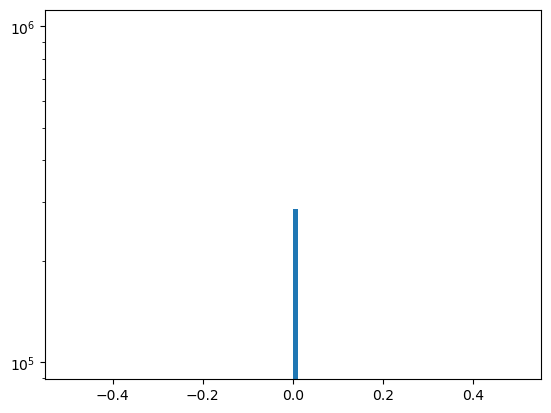

In [4]:
plt.hist(anno['am_pathogenicity'].drop_nulls(), bins=100, log=True)
plt.show()

In [5]:
selected_annos = anno_config_df.filter(
    # (pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation', 'splicing'])) # CDS
    # pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation']) # missense
    # pl.col('category').is_in(['genetic_diversity', 'conservation', 'splicing']) # 'splicing'

    (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation', 'regulatory_nondir'])) # non coding
    # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation'])) # introns
    # (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_star_llr_calibrated_mean', 'cadd_raw', 'pangolin_score', 'abexp_abs_max']))
)['annotation'].to_list()

melted_anno = (
    anno

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]),
        on="annotation",
        how="left"
    )

    .filter(
        # Remove null annotation scores
        (pl.col('annotation_score').is_not_null())
    )

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="average", descending=True).over(["annotation"]).cast(pl.Float32)
    )
    .drop(['annotation_score_dircor'])
)

melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank_desc
str,str,str,f32,str,i8,f32
"""chr6:131470655:G:A""","""ENSG00000118520""","""cadd_raw""",0.509206,"""genetic_diversity""",1,164907.5
"""chr1:177984374:G:A""","""ENSG00000120341""","""cadd_raw""",1.080405,"""genetic_diversity""",1,84910.0
"""chr4:72031791:C:T""","""ENSG00000056291""","""cadd_raw""",0.048837,"""genetic_diversity""",1,245681.0
"""chr15:64841764:A:C""","""ENSG00000241839""","""cadd_raw""",0.156522,"""genetic_diversity""",1,231117.5
"""chr6:26171655:A:C""","""ENSG00000274290""","""cadd_raw""",0.218032,"""genetic_diversity""",1,221264.0
…,…,…,…,…,…,…
"""chr11:68312453:T:A""","""ENSG00000162337""","""abexp_abs_max""",0.001705,"""regulatory_nondir""",1,244356.0
"""chr9:127854580:G:A""","""ENSG00000106991""","""abexp_abs_max""",0.018977,"""regulatory_nondir""",1,107065.5
"""chr11:68312255:C:T""","""ENSG00000162337""","""abexp_abs_max""",0.000569,"""regulatory_nondir""",1,265485.5


In [6]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
        .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)

In [7]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)

if pheno_list_type is not None:
    gene_trait_df = gene_trait_df.filter(pl.col('phenotype').is_in(pheno_list))

gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


## Odds ratio computation

In [8]:
n_steps = 101
min_rank_cutoff = 1000
max_rank_cutoff = 10_000_000
max_rank_cutoff = np.min([max_rank_cutoff, anno.shape[0]])
or_threshold_pheno = 0.99

# We assume that all models score the same number of variants (all the variants in 'anno')
log_steps = np.geomspace(min_rank_cutoff, max_rank_cutoff, n_steps)

cutoffs_lazy = pl.LazyFrame({"rank_cutoff": log_steps.astype(int)})

cutoffs_lazy.collect()

rank_cutoff
i64
1000
1058
1119
1184
1253
…
227669
240912
254926


In [9]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    .join(
        anno_ids_lazy, 
        on="id", 
        how="semi"
    )
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('corr_dir') == -1)
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
)

# Cross join with cutoffs and compute odds ratios
or_lazy = (
    gp_lazy
    # .select(["annotation", "region", "gene_name", "phenotype", "n_vars_above_ptile", "mean_pheno_value_dircor_ptile"])
    .select(["annotation", "region", "gene_name", "phenotype", "annotation_score_dircor_rank_desc", "mean_pheno_value_dircor_ptile"])
    .join(cutoffs_lazy, how="cross")
    .group_by(["annotation", "region", "gene_name", "phenotype", "rank_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") <= pl.col("rank_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") <= pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = or_lazy.collect(engine='streaming').sort('rank_cutoff', descending=True)

or_df

Executing with odds ratios...


annotation,region,gene_name,phenotype,rank_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,i64,u64,u64,u64,u64,f64
"""verphylop""","""ENSG00000036828""","""CASR""","""calcium_int""",285447,1,197,0,0,NaN
"""absplice2_max""","""ENSG00000118762""","""PKD2""","""creatinine_int""",285447,4,184,0,0,NaN
"""absplice2_max""","""ENSG00000101004""","""NINL""","""creatinine_int""",285447,3,299,0,0,NaN
"""abexp_abs_max""","""ENSG00000062282""","""DGAT2""","""direct_bilirubin_int""",285447,2,176,0,0,NaN
"""delta_score""","""ENSG00000096968""","""JAK2""","""eosinophill_count_int""",285447,7,327,0,0,NaN
…,…,…,…,…,…,…,…,…,…
"""pangolin_score""","""ENSG00000010327""","""STAB1""","""albumin_int""",1000,0,2,2,234,0.0
"""pangolin_score""","""ENSG00000110245""","""APOC3""","""apolipoprotein_a_int""",1000,0,1,3,164,0.0
"""absplice_dna_max""","""ENSG00000145386""","""CCNA2""","""leg_predicted_mass_left_int""",1000,0,1,1,195,0.0


## Plotting

In [10]:
# or_df.write_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_{or_threshold_pheno}_ranks_{min_rank_cutoff}_wgs_EUR_genebass1e6_maf1e3.parquet')
# or_df = pl.read_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_all_vars_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')

In [11]:
print('unique percentile cutoffs:', or_df['rank_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['rank_cutoff', 'annotation']),
        log_rank_cutoff = np.log10(pl.col('rank_cutoff')),
        log_rank_cutoff_inv = np.log10(1/pl.col('rank_cutoff')),
    )
    .with_columns(
        med_odds_ratio = pl.col('odds_ratio').median().over(['rank_cutoff', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['rank_cutoff', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['rank_cutoff', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'log_rank_cutoff', 'rank_cutoff', 'log_rank_cutoff_inv', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    .join(
        anno_config_df.select(['annotation', 'color', 'label', 'category']),
        on='annotation',
        how='left'
    )
    .sort('log_rank_cutoff')
    
    # Remove data points without ci or with or=0
    .filter(
        (pl.col('std_ci_upper').is_not_null()) &
        (pl.col('std_ci_lower').is_not_null()) &
        (pl.col('avg_odds_ratio') > 0) &
        (pl.col('std_ci_lower') > 0)
    )
)

plt_df

unique percentile cutoffs: 101


annotation,log_rank_cutoff,rank_cutoff,log_rank_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label,category
str,f64,i64,f64,u64,f64,f64,f64,f64,f64,str,str,str
"""absplice_dna_max""",3.0,1000,-3.0,373,0.0,0.867546,0.285579,1.42728,0.307812,"""#00838F""","""AbSplice (max)""","""splicing"""
"""cadd_raw""",3.0,1000,-3.0,307,0.0,1.395673,0.586653,2.545513,0.245833,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""gpn_score""",3.0,1000,-3.0,220,0.0,3.953352,1.059641,6.030249,1.876455,"""pink""","""GPN-MSA""","""conservation"""
"""gpn_star_llr_calibrated_mean""",3.0,1000,-3.0,254,0.0,5.843412,1.544815,8.871249,2.815575,"""#942c80""","""GPN-Star""","""conservation"""
"""verphylop""",3.0,1000,-3.0,143,0.0,1.286544,0.501175,2.268846,0.304242,"""#483D8B""","""Vertebrate PhyloP""","""conservation"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""cadd_raw""",5.43097,269755,-5.43097,164,0.185547,0.240277,0.018299,0.276143,0.20441,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""gpn_star_llr_calibrated_mean""",5.43097,269755,-5.43097,181,0.09009,0.119185,0.007738,0.134352,0.104019,"""#942c80""","""GPN-Star""","""conservation"""
"""abexp_abs_max""",5.43097,269755,-5.43097,97,0.277439,0.674948,0.1196,0.909364,0.440531,"""#80CBC4""","""AbExp abs max""","""regulatory_nondir"""


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/geoms/annotation_logticks.py:97: PlotnineWarning: annotation_logticks for x-axis which does not have a log scale. The logticks may not make sense.


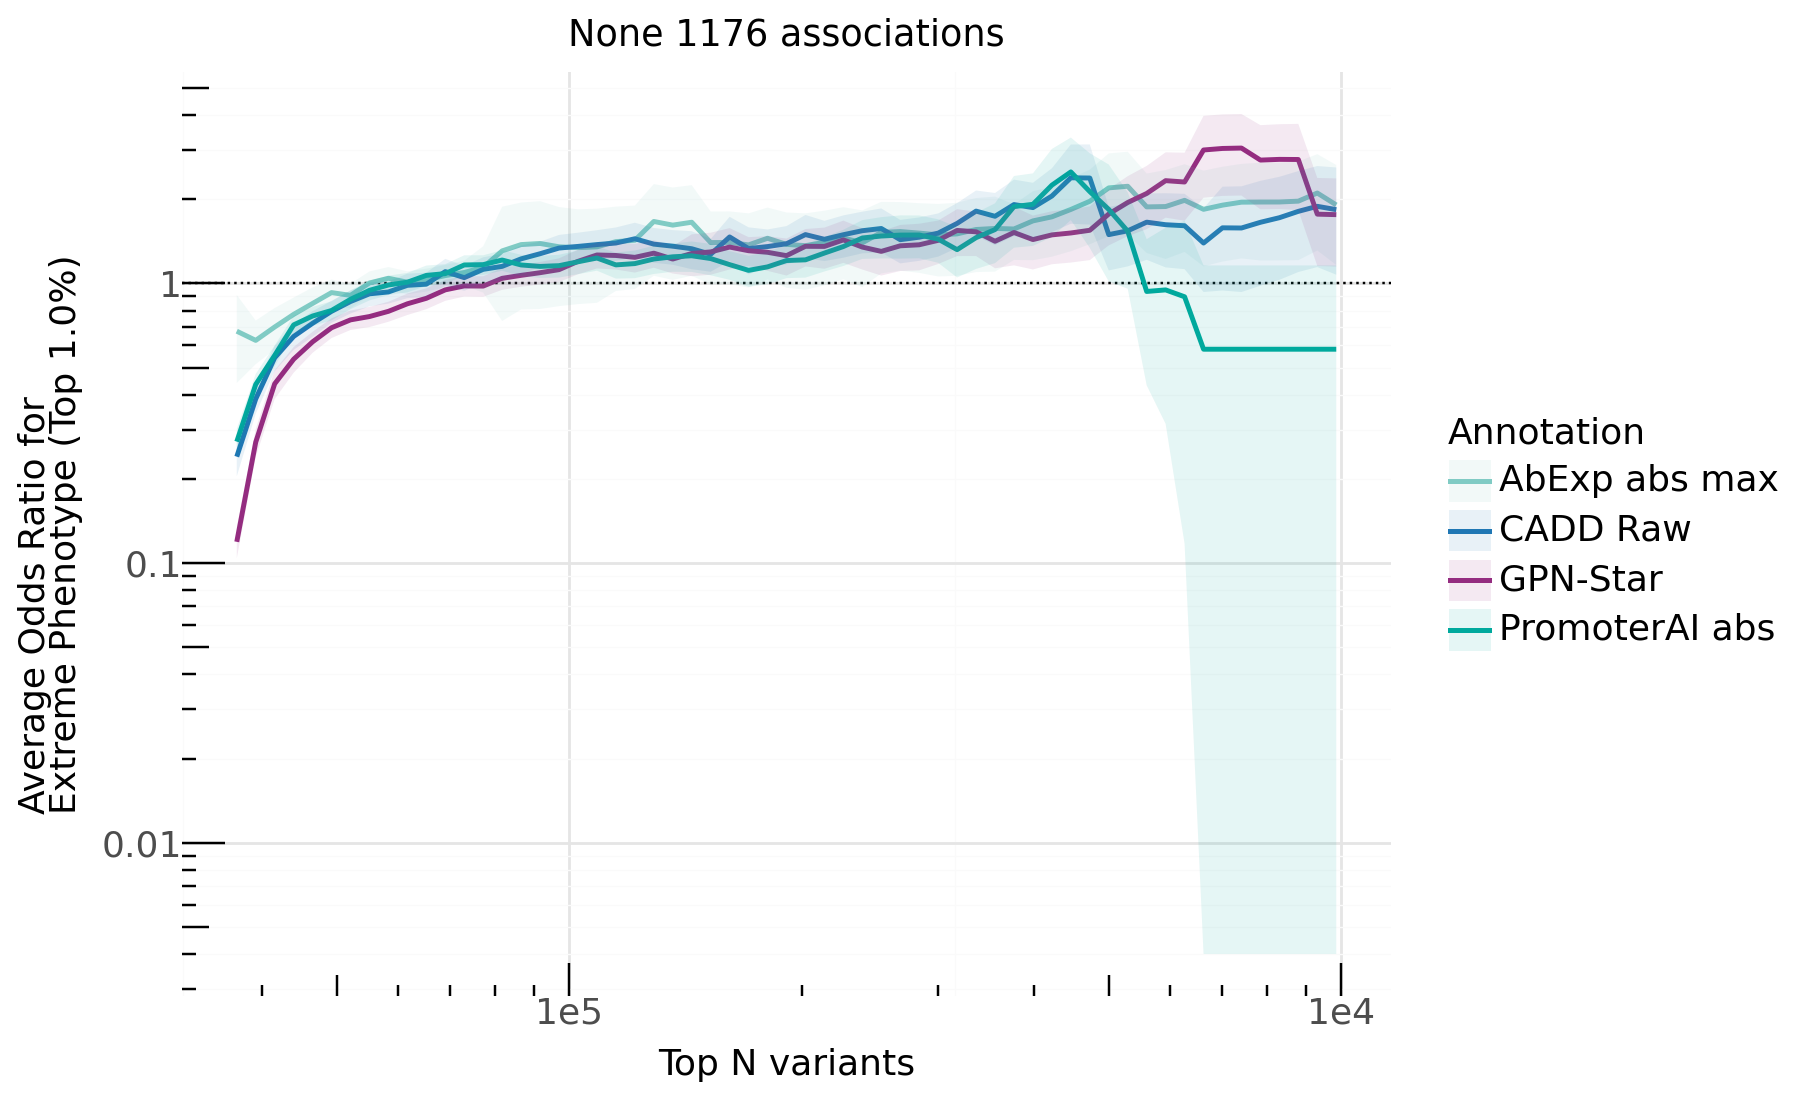

In [18]:
plot_df = (
    plt_df
    .filter(
        (pl.col('log_rank_cutoff_inv') <= -4) &

        # (pl.col('annotation').is_in(['am_pathogenicity', 'score_pai3d', 'esmscoremissense', 'gpn_star_llr_calibrated_mean']))
        # (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_star_llr_calibrated_mean', 'cadd_raw']))
        # (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_star_llr_calibrated_mean', 'cadd_raw', 'abexp_abs_max', 'pangolin_score']))
        # (pl.col('annotation').is_in(['gpn_star_llr_calibrated_mean', 'pangolin_score', 'abexp_abs_max']))
        (pl.col('annotation').is_in(['gpn_star_llr_calibrated_mean', 'cadd_raw', 'abexp_abs_max', 'promoterai_abs']))
        # (pl.col('category').is_in(['missense', 'genetic_diversity']))
    )
)

# Generate breaks and labels for x-axis
start_exp = int(np.log10(1/max_rank_cutoff))
end_exp = int(np.log10(1/min_rank_cutoff))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"1e{-b}" for b in breaks_linear]

# Determine legend order based on final average odds ratio
legend_order = (
    plot_df.sort("log_rank_cutoff_inv")
    .group_by("label", maintain_order=True)
    .last()
    .sort("avg_odds_ratio", descending=True)
    ['label']
    .to_list()
)

color_dict = dict(zip(plt_df['label'], plt_df['color']))
pheno_label = round((1 - or_threshold_pheno) * 100, 1)

loftee_or = pl.DataFrame({
    'region': ['gene_body_5kb', 'gene_body', 'cds'],
    'n_vars': [-np.log10(43_640), -np.log10(43_640), -np.log10(43_640)],
    'mean_or': [13.392815, 11.88451, 7.703493],
})

(
    ggplot(
        plot_df,
        aes(x='log_rank_cutoff_inv', y='avg_odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    # + geom_point(loftee_or.filter(pl.col('region')=='cds'), aes(x='n_vars', y='mean_or'), color='black', size=2)
    + scale_fill_manual(values=color_dict, limits=legend_order)
    + scale_color_manual(values=color_dict, limits=legend_order)
    + labs(
        title=f"{pheno_list_type} {gene_trait_df.shape[0]} associations",
        y=f"Average Odds Ratio for\nExtreme Phenotype (Top {pheno_label}%)",
        x="Top N variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    + annotation_logticks(sides="lb")
    + theme_minimal()
    + theme(
        figure_size=(9, 5.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [13]:
plt_df.head()

annotation,log_rank_cutoff,rank_cutoff,log_rank_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label,category
str,f64,i64,f64,u64,f64,f64,f64,f64,f64,str,str,str
"""absplice_dna_max""",3.0,1000,-3.0,373,0.0,0.867546,0.285579,1.42728,0.307812,"""#00838F""","""AbSplice (max)""","""splicing"""
"""cadd_raw""",3.0,1000,-3.0,307,0.0,1.395673,0.586653,2.545513,0.245833,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""gpn_score""",3.0,1000,-3.0,220,0.0,3.953352,1.059641,6.030249,1.876455,"""pink""","""GPN-MSA""","""conservation"""
"""gpn_star_llr_calibrated_mean""",3.0,1000,-3.0,254,0.0,5.843412,1.544815,8.871249,2.815575,"""#942c80""","""GPN-Star""","""conservation"""
"""verphylop""",3.0,1000,-3.0,143,0.0,1.286544,0.501175,2.268846,0.304242,"""#483D8B""","""Vertebrate PhyloP""","""conservation"""
